In [ ]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import cv2

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/monkeytype/monkeytyping.csv')
df.head()

,participant_id,date,original_filename,trial_number,reaction_time,correct,correct_position,chosen_position,prompt,sample_name,...,file_path,stimuli_quantity,colored,nut_quantity,juice_quantity,datetime,mean_reaction_time,percent_correct,omission_percent,experiment_duration
0,Jupiter,02.06.2025,02.06.2025 - Jupiter.txt,1,1029,0,2th,3th,NaN,NaN,...,/content/drive/MyDrive/Pavlov/Макаки учатся/Ex...,4.0,NaN,1.0,0.0,02.06.2025 11:59:45,980.0,35.0,4.0,"9 min, 35 sec"
1,Jupiter,02.06.2025,02.06.2025 - Jupiter.txt,2,579,1,2th,2th,NaN,NaN,...,/content/drive/MyDrive/Pavlov/Макаки учатся/Ex...,4.0,NaN,1.0,0.0,02.06.2025 11:59:45,980.0,35.0,4.0,"9 min, 35 sec"
2,Jupiter,02.06.2025,02.06.2025 - Jupiter.txt,3,688,0,3th,4th,NaN,NaN,...,/content/drive/MyDrive/Pavlov/Макаки учатся/Ex...,4.0,NaN,1.0,0.0,02.06.2025 11:59:45,980.0,35.0,4.0,"9 min, 35 sec"
3,Jupiter,02.06.2025,02.06.2025 - Jupiter.txt,4,578,0,4th,2th,NaN,NaN,...,/content/drive/MyDrive/Pavlov/Макаки учатся/Ex...,4.0,NaN,1.0,0.0,02.06.2025 11:59:45,980.0,35.0,4.0,"9 min, 35 sec"
4,Jupiter,02.06.2025,02.06.2025 - Jupiter.txt,5,848,1,4th,4th,NaN,NaN,...,/content/drive/MyDrive/Pavlov/Макаки учатся/Ex...,4.0,NaN,1.0,0.0,02.06.2025 11:59:45,980.0,35.0,4.0,"9 min, 35 sec"


In [ ]:
df_symbols = df[df['colored'].isna()].copy(deep=True)
df_symbols = df_symbols[df_symbols['file_3_name'].notna()].copy(deep=True)
#df_symbols.info()
image_filepath_main = '/content/drive/MyDrive/monkeytype/emnist_rare_ESRGAN_improved/'
file_cols_name = ['file_1_name', 'file_2_name', 'file_3_name', 'file_4_name']
for f in file_cols_name:
  df_symbols[f] = df_symbols[f].astype(str)
  for index, row in df_symbols.iterrows():
    df_symbols.loc[index, f] = df_symbols.loc[index, f][0] + '/'+df_symbols.loc[index, f][2:] + '_out.png'
print(df_symbols[file_cols_name[0]])

0       y/00902_out.png
1       s/00320_out.png
2       c/01270_out.png
3       f/00745_out.png
4       s/01180_out.png
             ...       
6154    f/01252_out.png
6155    m/01187_out.png
6156    m/00439_out.png
6157    m/00413_out.png
6158    c/00117_out.png
Name: file_1_name, Length: 5339, dtype: object


In [ ]:
df_files = df_symbols[file_cols_name].copy(deep = True)
df_files.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5339 entries, 0 to 6158
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   file_1_name  5339 non-null   object
 1   file_2_name  5339 non-null   object
 2   file_3_name  5339 non-null   object
 3   file_4_name  5339 non-null   object
dtypes: object(4)
memory usage: 337.6+ KB


In [ ]:
symbols_list = ['m', 'c', 's', 'y', 'f', 'j']

In [ ]:
new_file_cols = ['file_1_symb', 'file_2_symb', 'file_3_symb', 'file_4_symb']
for index, row in df_files.iterrows():
  for f, fs in zip(file_cols_name, new_file_cols):
    df_files.loc[index, fs] = df_files.loc[index, f][0]
df_files.head()

,file_1_name,file_2_name,file_3_name,file_4_name,file_1_symb,file_2_symb,file_3_symb,file_4_symb
0,y/00902_out.png,c/00891_out.png,f/01542_out.png,m/00280_out.png,y,c,f,m
1,s/00320_out.png,f/01788_out.png,m/01766_out.png,j/01080_out.png,s,f,m,j
2,c/01270_out.png,y/00523_out.png,j/01415_out.png,m/00902_out.png,c,y,j,m
3,f/00745_out.png,s/00125_out.png,m/01681_out.png,c/00697_out.png,f,s,m,c
4,s/01180_out.png,y/00443_out.png,j/01331_out.png,m/00367_out.png,s,y,j,m


In [ ]:
for index, row in df_files.iterrows():
  for f in file_cols_name:
    df_files.loc[index, f] = image_filepath_main + df_files.loc[index, f]
df_files.head()

,file_1_name,file_2_name,file_3_name,file_4_name,file_1_symb,file_2_symb,file_3_symb,file_4_symb
0,/content/drive/MyDrive/monkeytype/emnist_rare_...,/content/drive/MyDrive/monkeytype/emnist_rare_...,/content/drive/MyDrive/monkeytype/emnist_rare_...,/content/drive/MyDrive/monkeytype/emnist_rare_...,y,c,f,m
1,/content/drive/MyDrive/monkeytype/emnist_rare_...,/content/drive/MyDrive/monkeytype/emnist_rare_...,/content/drive/MyDrive/monkeytype/emnist_rare_...,/content/drive/MyDrive/monkeytype/emnist_rare_...,s,f,m,j
2,/content/drive/MyDrive/monkeytype/emnist_rare_...,/content/drive/MyDrive/monkeytype/emnist_rare_...,/content/drive/MyDrive/monkeytype/emnist_rare_...,/content/drive/MyDrive/monkeytype/emnist_rare_...,c,y,j,m
3,/content/drive/MyDrive/monkeytype/emnist_rare_...,/content/drive/MyDrive/monkeytype/emnist_rare_...,/content/drive/MyDrive/monkeytype/emnist_rare_...,/content/drive/MyDrive/monkeytype/emnist_rare_...,f,s,m,c
4,/content/drive/MyDrive/monkeytype/emnist_rare_...,/content/drive/MyDrive/monkeytype/emnist_rare_...,/content/drive/MyDrive/monkeytype/emnist_rare_...,/content/drive/MyDrive/monkeytype/emnist_rare_...,s,y,j,m


In [ ]:
df_bright_symbols = pd.DataFrame(columns=symbols_list)
for index, row in df_files.iterrows():
  index_ch = df_symbols.loc[index, 'chosen_position'][0]
  if index_ch!="N":
    df_bright_symbols.loc[index, 'participant_id'] = df_symbols.loc[index, 'participant_id']
    for f, fs in zip(file_cols_name, new_file_cols):
      img = cv2.imread(df_files.loc[index, f], cv2.IMREAD_GRAYSCALE)
      if img is None:
        print(f"Ошибка: не удалось загрузить изображение по пути: {df_files.loc[index, f]}")
      symbol = str(df_files.loc[index, fs])
      df_bright_symbols.loc[index, symbol] = np.mean(img)
      if index_ch in fs:
        df_bright_symbols.loc[index, 'chosen_symbol'] = df_files.loc[index, fs]
  if index%100==0:
    print(index)
df_bright_symbols.head()

0
100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
2000
2100
2200
2300
2400
2500
2600
2700
2800
2900
3000
3100
3200
3300
3400
3500
3600
3700
4600
4700
4800
4900
5000
5100
5200
5300
5400
5500
5600
5700
5800
5900
6000
6100


,m,c,s,y,f,j,participant_id,chosen_symbol
0,52.36352,35.222178,NaN,46.317761,35.280851,NaN,Jupiter,f
1,45.111926,NaN,56.269372,NaN,30.205277,39.408004,Jupiter,f
2,50.945871,55.413265,NaN,31.938776,NaN,35.726483,Jupiter,m
3,28.843033,48.010443,37.567443,NaN,33.661432,NaN,Jupiter,s
4,34.599649,NaN,64.20727,43.166454,NaN,26.046397,Jupiter,m


In [ ]:
df_bright_symbols.describe()

,m,c,s,y,f,j,participant_id,chosen_symbol
count,3065.000000,3099.000000,3099.000000,3166.000000,3127.000000,3144.000000,4675,4675
unique,1468.000000,1501.000000,1478.000000,1482.000000,1469.000000,1477.000000,3,6
top,41.234614,50.712691,58.302455,29.040418,32.093989,23.144611,Jupiter,y
freq,8.000000,8.000000,8.000000,8.000000,9.000000,8.000000,1687,1026


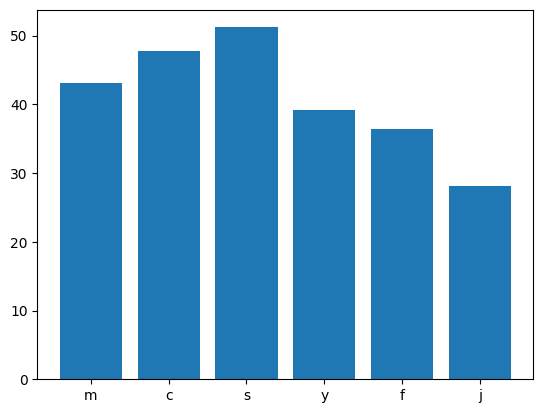

,m,c,s,y,f,j
0,43.155903,47.795978,51.209671,39.158014,36.344299,28.111612


In [ ]:
mean_values = df_bright_symbols[symbols_list].mean()

fig, ax = plt.subplots()
ax.bar(mean_values.index, mean_values.values, label=mean_values.values)
plt.show()

df_mean_values = pd.DataFrame([mean_values.values], columns=mean_values.index)
df_mean_values.head()

In [ ]:
df_Jupiter = df_symbols[df_symbols['participant_id']=='Jupiter'].copy(deep=True)
df_Jupiter['datetime'] = pd.to_datetime(df_Jupiter['datetime'], format='%d.%m.%Y %H:%M:%S')
df_Feliks = df_symbols[df_symbols['participant_id']=='Feliks'].copy(deep=True)
df_Feliks['datetime'] = pd.to_datetime(df_Feliks['datetime'], format='%d.%m.%Y %H:%M:%S')
df_Yunt = df_symbols[df_symbols['participant_id']=='Yunt'].copy(deep=True)
df_Yunt['datetime'] = pd.to_datetime(df_Yunt['datetime'], format='%d.%m.%Y %H:%M:%S')

In [ ]:
df_Jupiter.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2157 entries, 0 to 2156
Data columns (total 31 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   participant_id             2157 non-null   object        
 1   date                       2157 non-null   object        
 2   original_filename          2157 non-null   object        
 3   trial_number               2157 non-null   int64         
 4   reaction_time              2157 non-null   object        
 5   correct                    2157 non-null   int64         
 6   correct_position           2157 non-null   object        
 7   chosen_position            2157 non-null   object        
 8   prompt                     0 non-null      float64       
 9   sample_name                0 non-null      float64       
 10  file_1_name                2157 non-null   object        
 11  file_2_name                2157 non-null   object        
 12  file_3_name

In [ ]:
n_rows = 1
df_sym_hist_Yunt = pd.DataFrame(np.zeros((n_rows, len(symbols_list))),columns=symbols_list)
for index, row in df_Yunt.iterrows():
  f = ''
  index_ch = df_Yunt.loc[index, 'chosen_position'][0]
  if index_ch!="N":
    for i, s in enumerate(file_cols_name):
      if index_ch in s:
        f = file_cols_name[i]
    symbol2count = df_Yunt.loc[index, f][0]
    df_sym_hist_Yunt.loc[0, symbol2count]+=1.0


df_sym_hist_Jupiter = pd.DataFrame(np.zeros((n_rows, len(symbols_list))),columns=symbols_list)
for index, row in df_Jupiter.iterrows():
  f = ''
  index_ch = df_Jupiter.loc[index, 'chosen_position'][0]
  if index_ch!="N":
    for i, s in enumerate(file_cols_name):
      if index_ch in s:
        f = file_cols_name[i]
    symbol2count = df_Jupiter.loc[index, f][0]
    df_sym_hist_Jupiter.loc[0, symbol2count]+=1.0

df_sym_hist_Feliks = pd.DataFrame(np.zeros((n_rows, len(symbols_list))),columns=symbols_list)
for index, row in df_Feliks.iterrows():
  f = ''
  index_ch = df_Feliks.loc[index, 'chosen_position'][0]
  if index_ch!="N":
    for i, s in enumerate(file_cols_name):
      if index_ch in s:
        f = file_cols_name[i]
    symbol2count = df_Feliks.loc[index, f][0]
    df_sym_hist_Feliks.loc[0, symbol2count]+=1.0

In [ ]:
corr_Yunt = df_sym_hist_Yunt.corrwith(df_mean_values, axis=1)
corr_Jupiter = df_sym_hist_Jupiter.corrwith(df_mean_values, axis=1)
corr_Feliks = df_sym_hist_Feliks.corrwith(df_mean_values, axis=1)

print(corr_Jupiter, corr_Feliks, corr_Yunt)

0    0.504717
dtype: float64 0    0.899067
dtype: float64 0    0.64923
dtype: float64


In [ ]:
for index, row in df_bright_symbols.iterrows():
  sym = df_bright_symbols.loc[index, 'chosen_symbol']
  df_bright_symbols.loc[index, 'chosen_brightness'] = df_bright_symbols.loc[index, str(sym)]
df_bright_symbols.head()

,m,c,s,y,f,j,participant_id,chosen_symbol,chosen_brightness
0,52.36352,35.222178,NaN,46.317761,35.280851,NaN,Jupiter,f,35.280851
1,45.111926,NaN,56.269372,NaN,30.205277,39.408004,Jupiter,f,30.205277
2,50.945871,55.413265,NaN,31.938776,NaN,35.726483,Jupiter,m,50.945871
3,28.843033,48.010443,37.567443,NaN,33.661432,NaN,Jupiter,s,37.567443
4,34.599649,NaN,64.20727,43.166454,NaN,26.046397,Jupiter,m,34.599649


In [ ]:
df_b_s_Jupiter = df_bright_symbols[df_bright_symbols['participant_id']=='Jupiter']
df_b_s_Feliks = df_bright_symbols[df_bright_symbols['participant_id']=='Feliks']
df_b_s_Yunt = df_bright_symbols[df_bright_symbols['participant_id']=='Yunt']

[np.float64(0.0019171337704323224), np.float64(0.010612704800607498), np.float64(0.030126387821079372), np.float64(0.03300208847672783), np.float64(0.023211012434877044), np.float64(0.012119024191661476), np.float64(0.0032865150350268376), np.float64(0.0010955050116756126), np.float64(6.846906322972579e-05), np.float64(0.0)]
[0.0166073546856465, 0.09193357058125741, 0.2609727164887307, 0.2858837485172005, 0.20106761565836298, 0.10498220640569395, 0.028469750889679714, 0.009489916963226572, 0.0005931198102016608, 0.0]


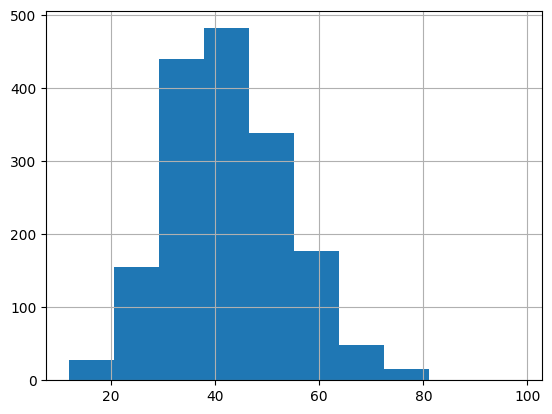

In [ ]:
df_b_s_Jupiter['chosen_brightness'].hist(bins=10)
data = df_b_s_Jupiter['chosen_brightness'].values

# количество корзин
bins = 10

# 1. границы корзин
min_v = data.min()
max_v = data.max()

bin_edges = np.linspace(min_v, max_v, bins + 1)

# 2. частоты вручную
hist = [0] * bins

for x in data:
    # находим корзину
    for i in range(bins):
        if bin_edges[i] <= x < bin_edges[i+1]:
            hist[i] += 1
            break
total = sum(hist)

bin_widths = [(bin_edges[i+1] - bin_edges[i]) for i in range(bins)]

density = [hist[i] / (total * bin_widths[i]) for i in range(bins)]

hist_norm = [h / total for h in hist]
print(density)
print(hist_norm)

In [ ]:
#перепроверка среднего времени реакции
segments = [g for _, g in df_Yunt.groupby('datetime')[['datetime', 'reaction_time', 'mean_reaction_time']]]
#print(segments[0])
for s in segments:
  mean_time=0.0
  iters = 0.0
  for index, row in s.iterrows():
    index_char = s.loc[index, 'reaction_time'][0]
    if index_char!="N":
      iters+=1.0
      mean_time+= float(s.loc[index, 'reaction_time'])
  mean_time/=iters
  for index, row in s.iterrows():
    s.loc[index, 'mean_reaction_time_recalculated'] = mean_time
print(segments[0])

                datetime reaction_time  mean_reaction_time  \
3609 2025-06-03 11:07:14     No answer              1127.0   
3610 2025-06-03 11:07:14     No answer              1127.0   
3611 2025-06-03 11:07:14     No answer              1127.0   
3612 2025-06-03 11:07:14     No answer              1127.0   
3613 2025-06-03 11:07:14     No answer              1127.0   
3614 2025-06-03 11:07:14     No answer              1127.0   
3615 2025-06-03 11:07:14     No answer              1127.0   
3616 2025-06-03 11:07:14     No answer              1127.0   
3617 2025-06-03 11:07:14     No answer              1127.0   
3618 2025-06-03 11:07:14          1619              1127.0   
3619 2025-06-03 11:07:14           253              1127.0   
3620 2025-06-03 11:07:14          1387              1127.0   
3621 2025-06-03 11:07:14          1053              1127.0   
3622 2025-06-03 11:07:14          1101              1127.0   
3623 2025-06-03 11:07:14     No answer              1127.0   
3624 202

In [ ]:
segments_rows=[i.iloc[0] for i in segments]
df_time_and_time = pd.DataFrame(segments_rows)
df_time_and_time.head()

,datetime,reaction_time,mean_reaction_time,mean_reaction_time_recalculated
3609,2025-06-03 11:07:14,No answer,1127.0,1127.736842
3659,2025-06-03 11:21:34,1412,1347.0,1347.214286
4509,2025-06-18 11:24:18,No answer,1259.0,1259.812500
4559,2025-06-18 11:39:42,2939,1386.0,1386.857143
4609,2025-06-19 10:40:20,3108,1204.0,1204.200000


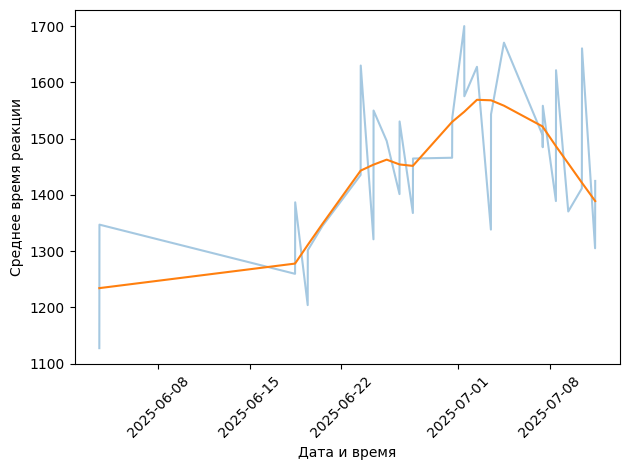

In [ ]:
import statsmodels.api as sm
lowess = sm.nonparametric.lowess
df_time_and_time['lowess'] = lowess(df_time_and_time['mean_reaction_time_recalculated'], df_time_and_time['datetime'], frac=0.4)[:,1]
plt.plot(df_time_and_time['datetime'], df_time_and_time['mean_reaction_time_recalculated'], alpha =0.4)
plt.plot(df_time_and_time['datetime'], df_time_and_time['lowess'])
plt.xlabel("Дата и время")
plt.ylabel("Среднее время реакции")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()